# PR #910 GLM 256k Seven-Datum Soak — Loss-per-Rep Analysis

**Run date:** 2026-08-06

This notebook plots the per-datum NLL (loss) across repetitions for the PR #910 soak,
and compares it against the previously validated fixed baseline (armH9) and the original
unfixed steady-state soak.

## Data sources

| Label | Path | Reps | Description |
|---|---|---:|---|
| **PR #910** (this run) | `full_logprobs_100rep.jsonl.gz` | 100 | New capture with PR #910 head |
| **armH9** (validated fix) | `../rearm/armH9_evidence/b4_h9_logprobs.jsonl.gz` | 31 | Fixed-wheel baseline (truncated gzip, 31 recoverable reps) |
| **Original unfixed** | `../ctrl/soak_0801_015956/soak.jsonl` | 146 | Original steady-state soak with loss spikes |

Each rep records 7 per-datum NLL values. NLL = mean negative log-probability per token for that datum.

In [1]:
import gzip
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

BASE = Path('.')  # notebook lives in pr910_256k_soak_20260806/

PR910_PATH = BASE / 'full_logprobs_100rep.jsonl.gz'
ARMH9_PATH = BASE / '..' / 'rearm' / 'armH9_evidence' / 'b4_h9_logprobs.jsonl.gz'
ORIG_PATH = BASE / '..' / 'ctrl' / 'soak_0801_015956' / 'soak.jsonl'

DOC_NAMES = [f'Doc {i}' for i in range(7)]
DOC_LENGTHS = [41380, 30060, 20895, 12168, 60180, 34646, 55181]
DOC_COLORS = plt.cm.tab10(np.linspace(0, 0.9, 7))

plt.rcParams.update({
    'figure.figsize': (14, 7),
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

## 1. Load all three datasets

In [2]:
def load_nlls_gz(path):
    """Load per-rep NLLs from a gzipped JSONL file (full logprobs format)."""
    reps, nlls = [], []
    with gzip.open(path, 'rt') as f:
        try:
            for line in f:
                rec = json.loads(line)
                reps.append(rec['rep'])
                nlls.append(rec['nlls'])
        except EOFError:
            pass  # truncated gzip (armH9)
    return np.array(reps), np.array(nlls)  # shape (n_reps, 7)

def load_nlls_plain(path):
    """Load per-rep NLLs from a plain JSONL file (original unfixed format)."""
    reps, nlls = [], []
    for line in path.read_text().splitlines():
        if not line.strip():
            continue
        rec = json.loads(line)
        if 'nlls' not in rec:
            continue
        reps.append(rec['rep'])
        nlls.append(rec['nlls'])
    return np.array(reps), np.array(nlls)

pr910_reps, pr910_nlls = load_nlls_gz(PR910_PATH)
armh9_reps, armh9_nlls = load_nlls_gz(ARMH9_PATH)
orig_reps, orig_nlls = load_nlls_plain(ORIG_PATH)

print(f'PR #910:  {len(pr910_reps)} reps  (expected 100)')
print(f'armH9:    {len(armh9_reps)} reps  (expected 31, truncated gzip)')
print(f'Original: {len(orig_reps)} reps  (expected 146)')

PR #910:  100 reps  (expected 100)
armH9:    31 reps  (expected 31, truncated gzip)
Original: 146 reps  (expected 146)


## 2. PR #910 — Loss per repetition for each document

All 7 datums on the same graph, one color per document. The x-axis is repetition index; the y-axis is the per-datum NLL (mean negative log-probability per token, in nats).

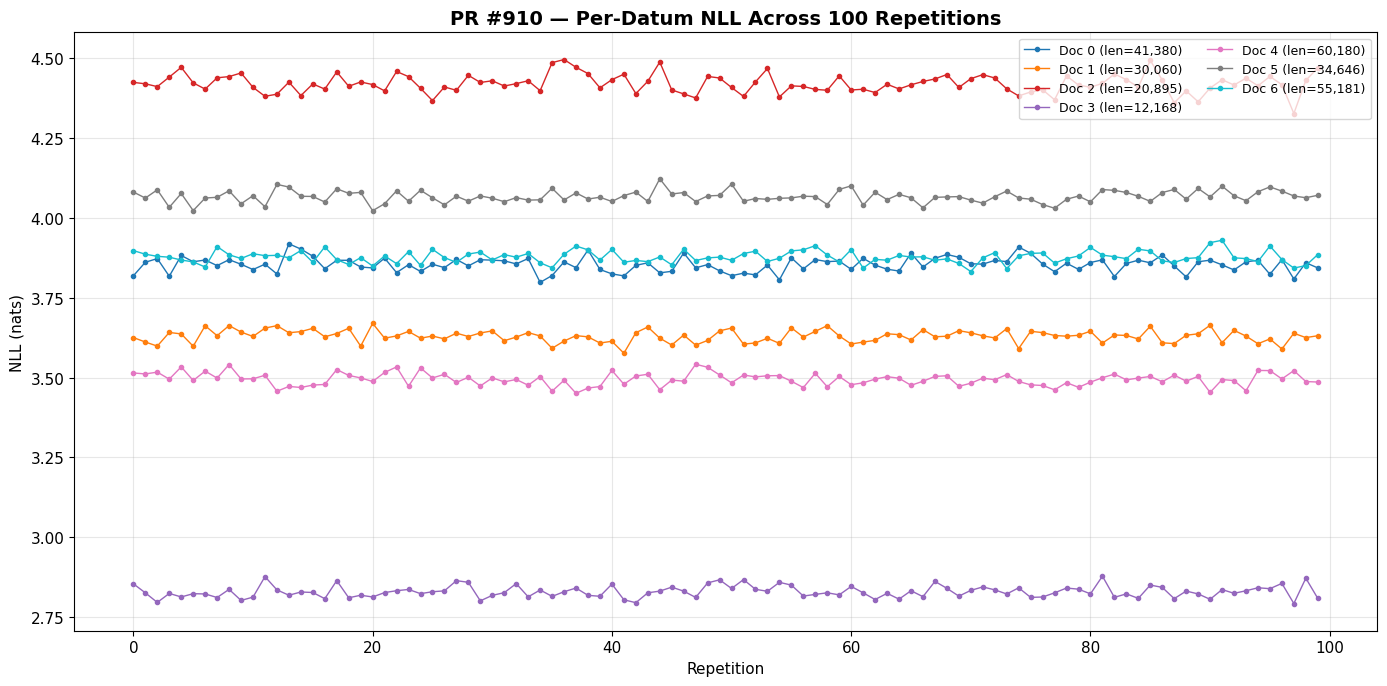

In [3]:
fig, ax = plt.subplots(figsize=(14, 7))

for doc in range(7):
    ax.plot(pr910_reps, pr910_nlls[:, doc], 'o-', markersize=3, linewidth=1,
            color=DOC_COLORS[doc], label=f'Doc {doc} (len={DOC_LENGTHS[doc]:,})')

ax.set_xlabel('Repetition')
ax.set_ylabel('NLL (nats)')
ax.set_title('PR #910 — Per-Datum NLL Across 100 Repetitions', fontsize=14, fontweight='bold')
ax.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.show()

## 3. PR #910 vs armH9 (validated fix) — per-datum comparison

Each document shown as a pair: solid line = PR #910, dashed line = armH9 baseline.
The armH9 baseline is the previously validated fix; this comparison checks whether PR #910 diverges from it.

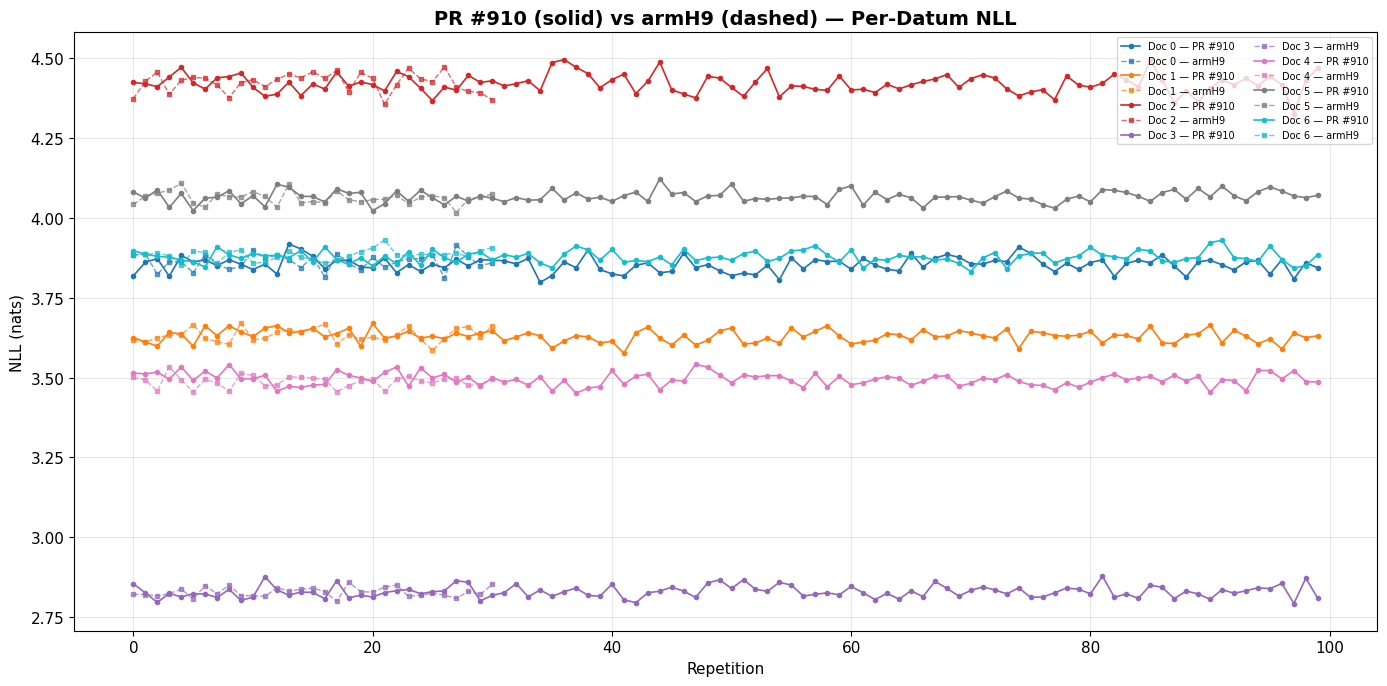

In [4]:
fig, ax = plt.subplots(figsize=(14, 7))

for doc in range(7):
    ax.plot(pr910_reps, pr910_nlls[:, doc], 'o-', markersize=3, linewidth=1.2,
            color=DOC_COLORS[doc], label=f'Doc {doc} — PR #910')
    ax.plot(armh9_reps, armh9_nlls[:, doc], 's--', markersize=3, linewidth=1, alpha=0.7,
            color=DOC_COLORS[doc], label=f'Doc {doc} — armH9')

ax.set_xlabel('Repetition')
ax.set_ylabel('NLL (nats)')
ax.set_title('PR #910 (solid) vs armH9 (dashed) — Per-Datum NLL', fontsize=14, fontweight='bold')
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

## 4. armH9 (validated fix) vs Original Unfixed — per-datum comparison

Each document shown as a pair: solid line = armH9 (fix), dashed line = original unfixed.
The original had 146 observations with 8 low-state reps (loss spikes).

Original low-state reps: [np.int64(2), np.int64(3), np.int64(5), np.int64(6), np.int64(8), np.int64(11), np.int64(13), np.int64(112)]


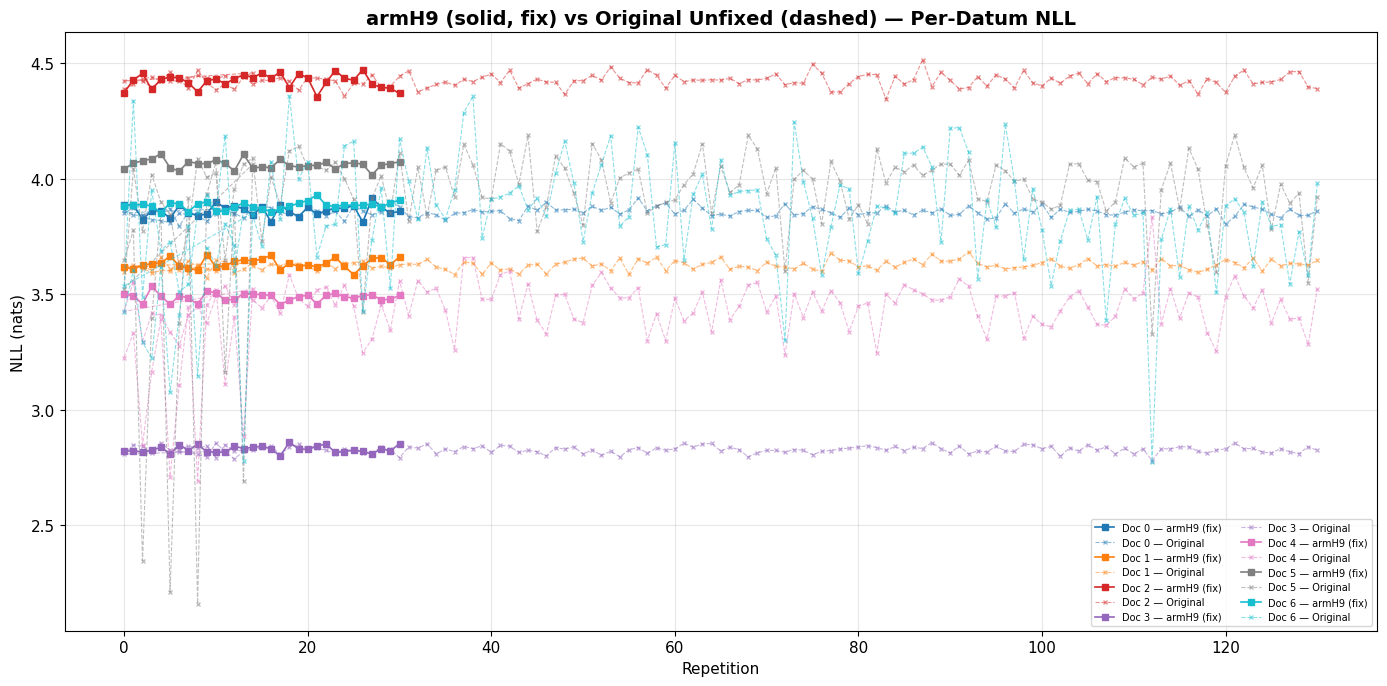

In [5]:
# Identify low-state reps in the original (any doc NLL < 3.2, excluding doc 0-3)
orig_low_reps = [orig_reps[i] for i in range(len(orig_reps)) if np.any(orig_nlls[i, 4:] < 3.2)]
print(f'Original low-state reps: {orig_low_reps}')

fig, ax = plt.subplots(figsize=(14, 7))

for doc in range(7):
    ax.plot(armh9_reps, armh9_nlls[:, doc], 's-', markersize=4, linewidth=1.2,
            color=DOC_COLORS[doc], label=f'Doc {doc} — armH9 (fix)')
    ax.plot(orig_reps, orig_nlls[:, doc], 'x--', markersize=3, linewidth=0.8, alpha=0.5,
            color=DOC_COLORS[doc], label=f'Doc {doc} — Original')

ax.set_xlabel('Repetition')
ax.set_ylabel('NLL (nats)')
ax.set_title('armH9 (solid, fix) vs Original Unfixed (dashed) — Per-Datum NLL', fontsize=14, fontweight='bold')
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

## 5. All three runs side-by-side

PR #910, armH9, and the original unfixed on the same graph to see the full progression:
original (spiking) -> armH9 (fixed) -> PR #910 (new, should match armH9).

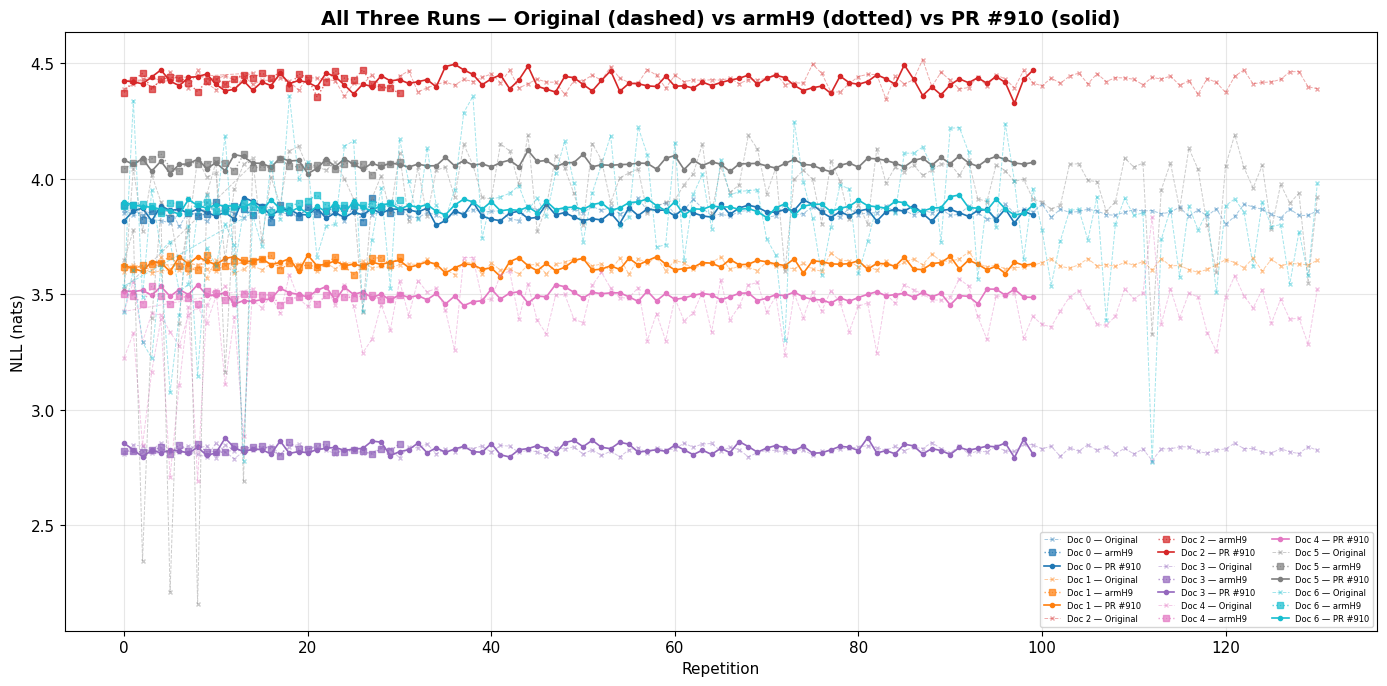

In [6]:
fig, ax = plt.subplots(figsize=(14, 7))

for doc in range(7):
    ax.plot(orig_reps, orig_nlls[:, doc], 'x--', markersize=3, linewidth=0.7, alpha=0.4,
            color=DOC_COLORS[doc], label=f'Doc {doc} — Original')
    ax.plot(armh9_reps, armh9_nlls[:, doc], 's:', markersize=4, linewidth=1, alpha=0.7,
            color=DOC_COLORS[doc], label=f'Doc {doc} — armH9')
    ax.plot(pr910_reps, pr910_nlls[:, doc], 'o-', markersize=3, linewidth=1.2,
            color=DOC_COLORS[doc], label=f'Doc {doc} — PR #910')

ax.set_xlabel('Repetition')
ax.set_ylabel('NLL (nats)')
ax.set_title('All Three Runs — Original (dashed) vs armH9 (dotted) vs PR #910 (solid)', fontsize=14, fontweight='bold')
ax.legend(fontsize=6, ncol=3)
plt.tight_layout()
plt.show()

## 6. Summary statistics

Per-datum mean NLL comparison across all three runs, plus the delta between PR #910 and armH9.

In [7]:
print(f"{'Doc':>4} | {'Length':>8} | {'Orig mean':>10} {'Orig med':>10} | {'armH9 mean':>11} {'armH9 std':>10} | {'PR910 mean':>11} {'PR910 std':>10} | {'D(PR910-armH9)':>14}")
print('-' * 110)
for doc in range(7):
    orig_mean = np.mean(orig_nlls[:, doc])
    orig_med = np.median(orig_nlls[:, doc])
    armh9_mean = np.mean(armh9_nlls[:, doc])
    armh9_std = np.std(armh9_nlls[:, doc], ddof=1)
    pr910_mean = np.mean(pr910_nlls[:, doc])
    pr910_std = np.std(pr910_nlls[:, doc], ddof=1)
    delta = pr910_mean - armh9_mean
    print(f'{doc:>4} | {DOC_LENGTHS[doc]:>8,} | {orig_mean:>10.5f} {orig_med:>10.5f} | {armh9_mean:>11.5f} {armh9_std:>10.5f} | {pr910_mean:>11.5f} {pr910_std:>10.5f} | {delta:>+14.5f}')

print()
print('Low-state reps (any doc>=4 NLL < 3.2):')
print(f'  Original: {len(orig_low_reps)} / {len(orig_reps)} reps  -> {orig_low_reps}')
print(f'  armH9:    {sum(1 for i in range(len(armh9_reps)) if np.any(armh9_nlls[i, 4:] < 3.2))} / {len(armh9_reps)} reps')
print(f'  PR #910:  {sum(1 for i in range(len(pr910_reps)) if np.any(pr910_nlls[i, 4:] < 3.2))} / {len(pr910_reps)} reps')

print()
print('Destroyed reps (any doc>=4 NLL > 4.4):')
print(f'  Original: {sum(1 for i in range(len(orig_reps)) if np.any(orig_nlls[i, 4:] > 4.4))} / {len(orig_reps)} reps')
print(f'  armH9:    {sum(1 for i in range(len(armh9_reps)) if np.any(armh9_nlls[i, 4:] > 4.4))} / {len(armh9_reps)} reps')
print(f'  PR #910:  {sum(1 for i in range(len(pr910_reps)) if np.any(pr910_nlls[i, 4:] > 4.4))} / {len(pr910_reps)} reps')

 Doc |   Length |  Orig mean   Orig med |  armH9 mean  armH9 std |  PR910 mean  PR910 std | D(PR910-armH9)
--------------------------------------------------------------------------------------------------------------
   0 |   41,380 |    3.85602    3.85562 |     3.86233    0.02458 |     3.85342    0.02304 |       -0.00891
   1 |   30,060 |    3.62522    3.62507 |     3.63278    0.02145 |     3.62949    0.01910 |       -0.00329
   2 |   20,895 |    4.42443    4.42532 |     4.42236    0.03055 |     4.41932    0.02971 |       -0.00304
   3 |   12,168 |    2.82682    2.82753 |     2.82885    0.01478 |     2.83019    0.01887 |       +0.00134
   4 |   60,180 |    3.42601    3.45390 |     3.48769    0.01831 |     3.49450    0.01981 |       +0.00681
   5 |   34,646 |    3.89789    3.98435 |     4.06195    0.01975 |     4.06620    0.01861 |       +0.00425
   6 |   55,181 |    3.82354    3.85188 |     3.88339    0.01664 |     3.87728    0.01891 |       -0.00611

Low-state reps (any doc>=4 NLL <

## 7. Box-plot comparison

Box plots showing the distribution of per-datum NLL across reps for each run.

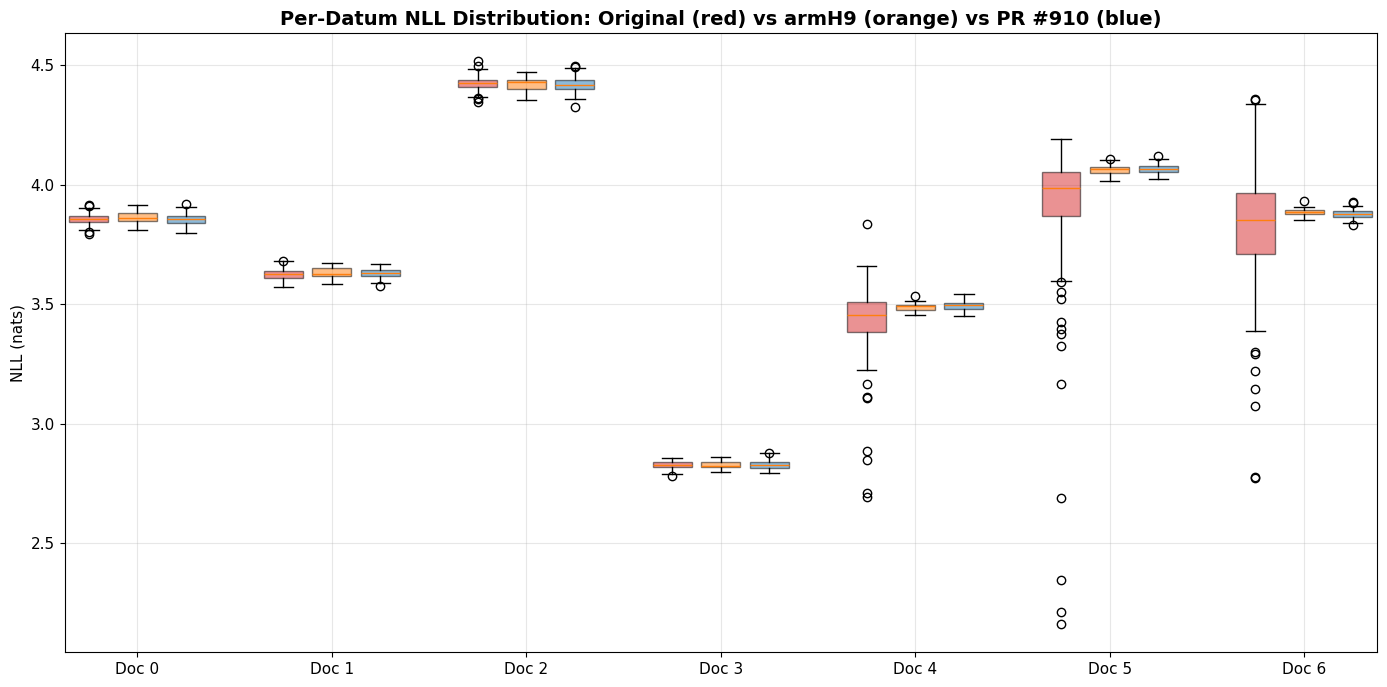

In [8]:
fig, ax = plt.subplots(figsize=(14, 7))

positions = []
box_data = []
colors_list = []
labels_list = []

for doc in range(7):
    base = doc * 4
    for j, (nlls_arr, run_name, marker_color) in enumerate([
        (orig_nlls, 'Orig', 'tab:red'),
        (armh9_nlls, 'armH9', 'tab:orange'),
        (pr910_nlls, 'PR910', 'tab:blue'),
    ]):
        positions.append(base + j)
        box_data.append(nlls_arr[:, doc])
        colors_list.append(marker_color)
        labels_list.append(f'D{doc} {run_name}')

bp = ax.boxplot(box_data, positions=positions, widths=0.8, patch_artist=True)
for patch, color in zip(bp['boxes'], colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)

ax.set_xticks([d * 4 + 1 for d in range(7)])
ax.set_xticklabels([f'Doc {d}' for d in range(7)])
ax.set_ylabel('NLL (nats)')
ax.set_title('Per-Datum NLL Distribution: Original (red) vs armH9 (orange) vs PR #910 (blue)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()